#### LAB NUMBER - 02
#### DATE - 07/02/2026
#### NAME - R K LARIKA
#### ROLL NO - CS23B1028

#### QUESTION 1

Classify MNIST digits using Fully Connected Neural network.
Dataset : Download from internet source

- Plot few samples from dataset
- Train the network 
- Test on the test dataset
- Calculate test accuracy on test set


#### Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


#### Loading MNIST dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [01:10<00:00, 140kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:08<00:00, 198kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.11MB/s]


#### Plotting few samples

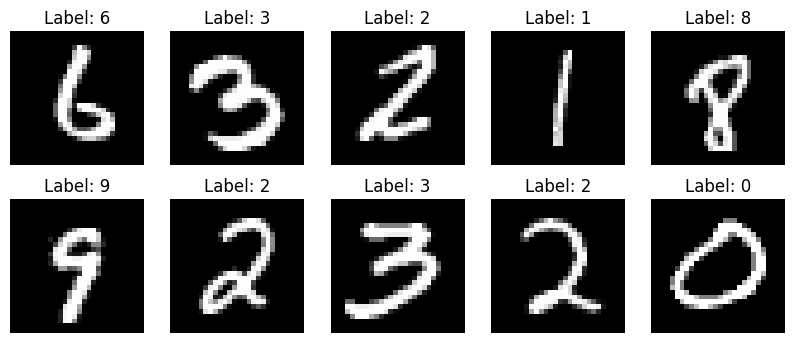

In [3]:
examples = iter(train_loader)
images, labels = next(examples)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()


#### Defining the Neural Network

In [4]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(-1, 28*28)   # flatten
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FCNN()
print(model)


FCNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


I defined a fully connected neural network with input size 784 corresponding to flattened 28×28 MNIST images, two hidden layers of 128 and 64 neurons with ReLU activation, and an output layer of 10 neurons for digit classes.

Why ReLu ?
    Because it avoids vanishing gradient, faster training, better than sigmoid/tanh for hidden layers.

Why no Softmax in last layer?
    Because we use Cross entropy loss, it internally applies softmax.



#### Define Loss Function and Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


I used CrossEntropyLoss because the task is multi-class digit classification and this loss function directly compares predicted class probabilities with true labels. I used Adam optimizer because it provides adaptive learning rates and faster convergence, making it suitable for training neural networks efficiently

#### Train the NN

In [6]:
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.3834
Epoch [2/5], Loss: 0.1787
Epoch [3/5], Loss: 0.1292
Epoch [4/5], Loss: 0.1065
Epoch [5/5], Loss: 0.0887


#### Test on Test Dataset

In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.08%


We got a test accuracy of 97.08%
This shows:
- The model has learned meaningful patterns
- Generalizes well to unseen test data.
- Performance is good for a fully connected network

Why is accuracy not 100%?
Because:
- Some digits look similar (e.g., 4 vs 9, 3 vs 5)
- Fully connected networks do not capture spatial features as well as CNNs
- Handwriting styles vary
- Some samples are ambiguous

So small errors are expected.

#### Test on Images

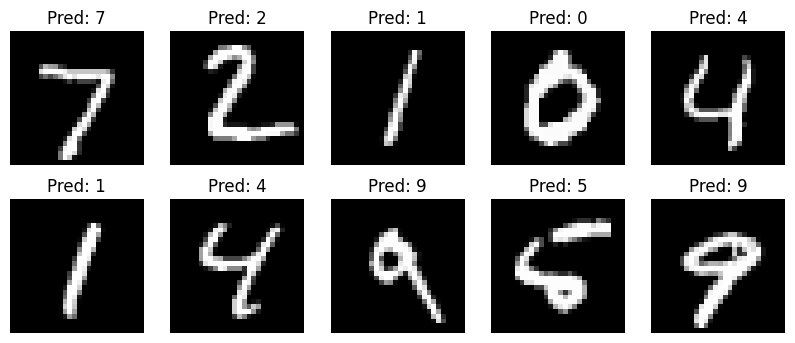

In [8]:
examples = iter(test_loader)
images, labels = next(examples)
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Pred: {preds[i].item()}")
    plt.axis('off')
plt.show()
